# Maglev Paper — All Figures
Reproduces Figures 2–6 from *Dynamic Stability and Levitation Control in Maglev Systems*.

**Figure list:**
- Fig 1: Schematic (not generated here — experimental photo + diagram)
- Fig 2: Bz field profiles vs transverse position x
- Fig 3: Magnetic field lines in vertical plane (y=0)
- Fig 4: Levitation gap vs added mass (fit + data)
- Fig 5: Passenger capacity vs remanent flux density Br (TR08 scaling)
- Fig 6: Potential energy landscape (Umag, m0gh, Utotal)

## 0. Imports and shared parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import least_squares, brentq
from scipy.integrate import cumulative_trapezoid

# ── Physical constants ──────────────────────────────────────────────────────
mu_0 = 4 * np.pi * 1e-7   # H/m
g    = 9.81                # m/s^2

# ── Rail geometry (half-dimensions) ─────────────────────────────────────────
a     = 6.25e-3   # m  half-width  (2a = 1.25 cm)
b     = 6.25e-2   # m  half-length (2b = 12.5 cm)
delta = 0.8e-3    # m  tape thickness
m0    = 62e-3     # kg empty train mass

# ── Global plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'axes.labelsize'  : 20,
    'xtick.labelsize' : 18,
    'ytick.labelsize' : 18,
    'legend.fontsize' : 16,
    'lines.linewidth' : 2.5,
})

print('Parameters loaded.')

Parameters loaded.


## Shared force kernel (Akoun-Yonnet validated)

In [2]:
def A_kernel(u, v, w):
    """Primitive A(u,v,w) validated against Akoun & Yonnet (1984)."""
    u, v, w = np.abs(u)+1e-15, np.abs(v)+1e-15, np.abs(w)+1e-15
    R   = np.sqrt(u**2 + v**2 + w**2)
    rho = np.sqrt(u**2 + v**2)
    t0  =  u*v * np.arctan((v*u) / (w*R))
    t2  =  w*u * np.log(R + u)
    t3  = -0.5 * w * R
    t4  =  0.5 * (u**2 - v**2) * np.log((R + w) / (rho + 1e-18))
    t5  = -0.5 * u * w * np.log(v**2 + w**2)
    return t2 + t3 + t4 + t5 + t0/2

def A_sym(u, v, w):
    """Symmetrised primitive: A(u,v,w) + A(v,u,w)."""
    return A_kernel(u, v, w) + A_kernel(v, u, w)

def S(z):
    """Flux surface primitive S(z) — Eq.(6) of the paper."""
    return (  A_sym(2*a, 2*b, z)
            - A_sym(2*a, 0,   z)
            - A_sym(0,   2*b, z)
            + A_sym(0,   0,   z))

def G(h):
    """Second finite difference of S — force shape function."""
    return S(h + 2*delta) - 2*S(h + delta) + S(h)

def F_pair(h, K):
    """Repulsive force from ONE rail pair. K = mu0*M^2/pi = Pmag."""
    return K * G(h)

def F_total(h, K):
    """Total upward force from TWO rail pairs."""
    return 2 * np.abs(F_pair(h, K))

print('Force kernels defined.')

Force kernels defined.


## Fit K (Pmag) to experimental data

In [3]:
# ── Experimental data ───────────────────────────────────────────────────────
m_exp_g  = np.array([0,5,15,20,26,31,36,43,51,63,
                     71,85,90,103,117,124,135,166,180,192,
                     217,259,289,307,322], float)
h_exp_mm = np.array([5,4.8,4.3,4,3.7,3.5,3.3,2.9,2.8,2.8,
                     2.7,2.1,2,1.9,1.7,1.5,1.5,1.4,1.4,1.3,
                     1.2,1,0.8,0.5,0], float)
m_exp = m_exp_g  * 1e-3
h_exp = h_exp_mm * 1e-3
u_m   = 1.0e-3   # kg
u_h   = 0.5e-3   # m

# exclude contact point h=0
mask   = h_exp > 0
m_fit  = m_exp[mask]
h_fit  = h_exp[mask]

# ── Least-squares fit: single free parameter logK ───────────────────────────
def residuals(params):
    K = np.exp(params[0])
    m_pred = F_total(h_fit, K) / g - m0
    return (m_pred - m_fit) / u_m

res   = least_squares(residuals, x0=[np.log(1e-3)])
K_hat = float(np.exp(res.x[0]))
M_hat = np.sqrt(K_hat * np.pi / mu_0)

# R²
def h_from_m(m_kg, hmin=1e-6, hmax=12e-3):
    target = (m_kg + m0) * g
    def fun(h): return F_total(h, K_hat) - target
    if fun(hmin) * fun(hmax) > 0: return np.nan
    return brentq(fun, hmin, hmax, maxiter=300)

h_pred_fit = np.array([h_from_m(m) for m in m_fit])
ss_res = np.nansum((h_fit - h_pred_fit)**2)
ss_tot = np.sum((h_fit - np.mean(h_fit))**2)
R2 = 1 - ss_res / ss_tot

print(f'K_hat  (Pmag) = {K_hat:.4e} Pa')
print(f'M_hat         = {M_hat:.4e} A/m')
print(f'R²            = {R2:.4f}')

K_hat  (Pmag) = 2.8103e+04 Pa
M_hat         = 2.6506e+05 A/m
R²            = 0.9633


---
## Figure 2 — Bz field profiles

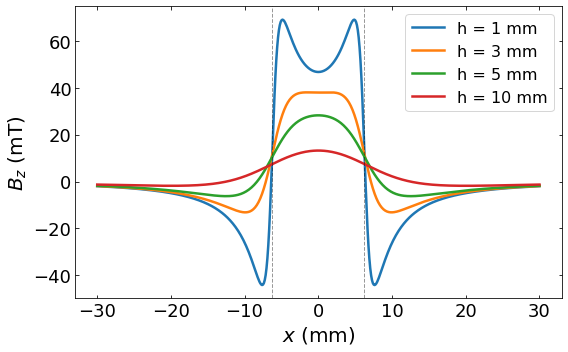

In [4]:
plt.rcParams.update({
    'axes.labelsize'  : 20,
    'xtick.labelsize' : 18,
    'ytick.labelsize' : 18,
    'legend.fontsize' : 16,
    'lines.linewidth' : 2.5,
})
 
Br = 1.2   # T  (used for normalised display only)
 
def bz_point(x, y, z):
    """Single-surface Bz (Hampton formula)."""
    x1, x2 = x - a, x + a
    y1, y2 = y - b, y + b
    def term(xc, yc, zc):
        r = np.sqrt(xc**2 + yc**2 + zc**2)
        return np.arctan2(xc*yc, zc*r)
    val = (term(x2,y2,z) - term(x1,y2,z)
          - term(x2,y1,z) + term(x1,y1,z))
    return (Br / (4*np.pi)) * val
 
def bz_total(x, h):
    """Bz from slab of thickness delta at height h."""
    return bz_point(x, 0, h) - bz_point(x, 0, h+delta)
 
x_axis = np.linspace(-0.03, 0.03, 500)
 
fig, ax = plt.subplots(figsize=(8, 5))
for h_mm, col, lbl in zip([1, 3, 5, 10],
                            ['tab:blue','tab:orange','tab:green','tab:red'],
                            ['h = 1 mm','h = 3 mm','h = 5 mm','h = 10 mm']):
    y_plot = np.array([bz_total(x, h_mm*1e-3)*1e3 for x in x_axis])
    ax.plot(x_axis*1e3, y_plot, color=col, label=lbl)
 
ax.axvline( a*1e3, color='k', linestyle='--', linewidth=1, alpha=0.4)
ax.axvline(-a*1e3, color='k', linestyle='--', linewidth=1, alpha=0.4)
ax.set_xlabel('$x$ (mm)')
ax.set_ylabel('$B_z$ (mT)')
ax.legend()
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()


---
## Figure 3 — Magnetic field lines in vertical plane (y=0)

Computing panel (a)...
Computing panel (b)...


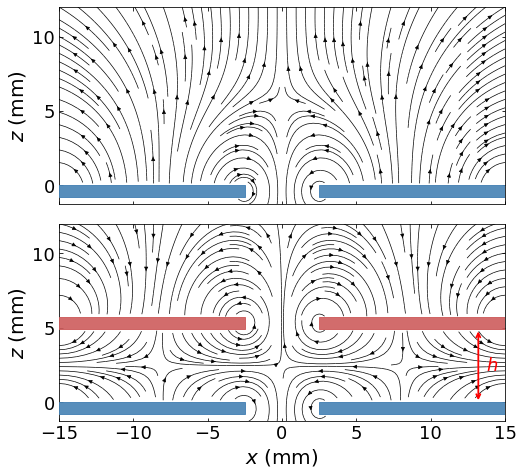

In [5]:

import numpy as np
import matplotlib.pyplot as plt

mu_0  = 4*np.pi*1e-7
M     = 2.5e5
a     = 6.25e-3
b     = 6.25e-2
delta = 0.8e-3
h_eq  = 4.9e-3
gap   = 5e-3
cx_left  = -(gap/2 + a)
cx_right =  (gap/2 + a)
z_max    = 12e-3

def _field_one_rail(x, z, cx, z1, z2, sign):
    """
    Bx, Bz from one z-magnetized cuboid at (x, y=0, z).
    sign=+1: magnetized +z (north on top).
    Magnet occupies x in [cx-a,cx+a], y in [-b,b], z in [z1,z2].
    Verified sign convention:
      Bz: pre = -mu0*M/4pi  (gives Bz>0 above north pole)
      Bx: pre = +mu0*M/4pi  (gives Bx pointing away from magnet at sides)
    """
    x1, x2 = cx-a, cx+a
    y1, y2 = -b, b
    U = [x-x1, x-x2]
    V = [0.-y1, 0.-y2]   # y=0
    W = [z-z1, z-z2]
    Bz_sum = 0.; Bx_sum = 0.
    for i in range(2):
        for j in range(2):
            for k in range(2):
                s = (-1)**(i+j+k)
                R = np.sqrt(U[i]**2 + V[j]**2 + W[k]**2) + 1e-30
                # Bz
                den = W[k]*R
                if abs(den) > 1e-30:
                    Bz_sum += s * np.arctan(U[i]*V[j] / den)
                # Bx
                arg = V[j] + R
                if arg > 1e-30:
                    Bx_sum += s * np.log(arg)
    pre = mu_0*M/(4*np.pi)
    return sign*(+pre)*Bx_sum, sign*(-pre)*Bz_sum

def compute_field(x_arr, z_arr, rails):
    """rails: list of (cx, z_bot, z_top, sign)"""
    X, Z = np.meshgrid(x_arr, z_arr)
    Bx = np.zeros_like(X)
    Bz = np.zeros_like(X)
    for (cx, z1, z2, sign) in rails:
        for i in range(Z.shape[0]):
            for j in range(Z.shape[1]):
                bx, bz = _field_one_rail(X[i,j], Z[i,j], cx, z1, z2, sign)
                Bx[i,j] += bx; Bz[i,j] += bz
    return Bx, Bz

def mask_rails(Bx, Bz, rects):
    X, Z = np.meshgrid(x_arr, z_arr)
    for (xlo, xhi, zlo, zhi) in rects:
        m = (X>=xlo)&(X<=xhi)&(Z>=zlo)&(Z<=zhi)
        Bx[m] = np.nan; Bz[m] = np.nan

Nx, Nz = 130, 105
x_arr = np.linspace(-15e-3, 15e-3, Nx)
z_arr = np.linspace(-1.6*delta, z_max, Nz)

# Lower rails: bottom at -delta, top at 0, magnetized +z (north on top)
lower_rails = [(cx_left,  -delta, 0., +1),
               (cx_right, -delta, 0., +1)]

# Upper rails for repulsion: north face points DOWN into gap
# -> magnetized -z: bottom at h_eq, top at h_eq+delta
upper_rails = [(cx_left,  h_eq, h_eq+delta, -1),
               (cx_right, h_eq, h_eq+delta, -1)]

print("Computing panel (a)...")
Bx_a, Bz_a = compute_field(x_arr, z_arr, lower_rails)
print("Computing panel (b)...")
Bx_b, Bz_b = compute_field(x_arr, z_arr, lower_rails + upper_rails)

lo_rects = [((cx-a),(cx+a),-delta,0.)       for cx in [cx_left,cx_right]]
up_rects = [((cx-a),(cx+a),h_eq,h_eq+delta) for cx in [cx_left,cx_right]]
mask_rails(Bx_a, Bz_a, lo_rects)
mask_rails(Bx_b, Bz_b, lo_rects + up_rects)

# ── Plot ─────────────────────────────────────────────────────────────────
plt.rcParams.update({'axes.labelsize':20,'xtick.labelsize':18,'ytick.labelsize':18})


panel_w = 8.0
panel_h = panel_w / (30/13.28)   # ~3.54 inches per panel
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(panel_w, 2*panel_h + 0.6),
                                gridspec_kw={'hspace': 0.08})
xmm = x_arr*1e3; zmm = z_arr*1e3
ylo = -1.6*delta*1e3; yhi = z_max*1e3

def draw_lower(ax):
    for cx in [cx_left, cx_right]:
        ax.add_patch(plt.Rectangle(((cx-a)*1e3, -delta*1e3),
                     2*a*1e3, delta*1e3, color='steelblue', alpha=0.9, zorder=5))

def draw_upper(ax):
    for cx in [cx_left, cx_right]:
        ax.add_patch(plt.Rectangle(((cx-a)*1e3, h_eq*1e3),
                     2*a*1e3, delta*1e3, color='indianred', alpha=0.9, zorder=5))

ax1.streamplot(xmm, zmm, Bx_a, Bz_a, color='black',
               density=1.6, linewidth=0.7, arrowsize=0.8)
draw_lower(ax1)
ax1.set_ylabel('$z$ (mm)', fontsize=20)
ax1.tick_params(axis='both', labelsize=18, direction='in', top=True, right=True)
ax1.set_xlim(-15, 15); ax1.set_ylim(ylo, yhi)
ax1.set_xticklabels([]); ax1.set_aspect('equal')

ax2.streamplot(xmm, zmm, Bx_b, Bz_b, color='black',
               density=1.6, linewidth=0.7, arrowsize=0.8)
draw_lower(ax2); draw_upper(ax2)
xan = 13.2
ax2.annotate('', xy=(xan, 0), xytext=(xan, h_eq*1e3),
             arrowprops=dict(arrowstyle='<->', color='red', lw=1.8))
ax2.text(xan+0.5, h_eq*1e3/2, '$h$', fontsize=18, color='red', va='center')
ax2.set_xlabel('$x$ (mm)', fontsize=20); ax2.set_ylabel('$z$ (mm)', fontsize=20)
ax2.tick_params(axis='both', labelsize=18, direction='in', top=True, right=True)
ax2.set_xlim(-15, 15); ax2.set_ylim(ylo, yhi); ax2.set_aspect('equal')

plt.show()

---
## Figure 4 — Levitation gap vs added mass

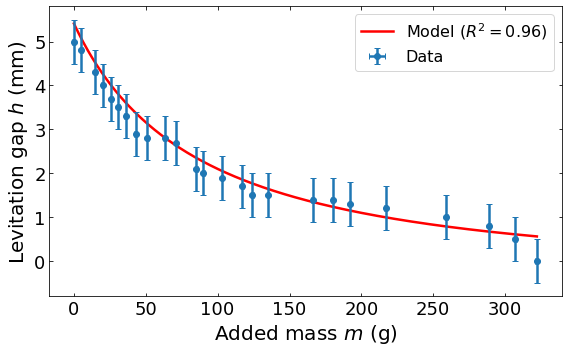

In [6]:
m_grid_g = np.linspace(m_exp_g.min(), m_exp_g.max(), 300)
m_grid   = m_grid_g * 1e-3
h_grid   = np.array([h_from_m(m) for m in m_grid])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(m_exp_g, h_exp_mm, xerr=1.0, yerr=0.5,
            fmt='o', capsize=3, label='Data', zorder=5)
ax.plot(m_grid_g, h_grid*1e3, 'r-',
        label=f'Model ($R^2={R2:.2f}$)')
ax.set_xlabel('Added mass $m$ (g)')
ax.set_ylabel('Levitation gap $h$ (mm)')
ax.legend()
ax.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.show()


---
## Figure 5 — Passenger capacity vs Br (TR08 scaling)

Br_empty=1.187 T, Br_loaded=1.365 T


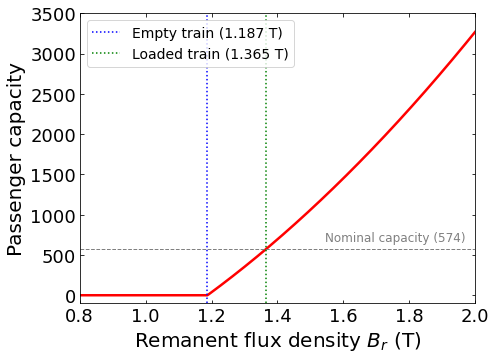

In [7]:

import numpy as np
import matplotlib.pyplot as plt

mu_0=4*np.pi*1e-7; g=9.81
m0_train=188.5e3; n_pass_nom=574; m_pass=80.
m_empty=m0_train-n_pass_nom*m_pass
a_fs=0.06; b_fs=0.50; delta_fs=0.03; h_fs=10e-3; N_pairs=158

def A_kernel(u,v,w):
    u,v,w=np.abs(u)+1e-15,np.abs(v)+1e-15,np.abs(w)+1e-15
    R=np.sqrt(u**2+v**2+w**2)
    return (w*u*np.log(R+u) - 0.5*w*R
            + 0.5*(u**2-v**2)*np.log((R+w)/(np.sqrt(u**2+v**2)+1e-18))
            - 0.5*u*w*np.log(v**2+w**2)
            + 0.5*u*v*np.arctan(u*v/(w*R)))

def A_sym(u,v,w): return A_kernel(u,v,w)+A_kernel(v,u,w)
def S(z): return A_sym(2*a_fs,2*b_fs,z)-A_sym(2*a_fs,0,z)-A_sym(0,2*b_fs,z)+A_sym(0,0,z)
def G(h): return S(h+2*delta_fs)-2*S(h+delta_fs)+S(h)
G_val=abs(G(h_fs))

Br_arr=np.linspace(0.8,2.0,500)
payload_arr=np.array([N_pairs*(mu_0*(Br/mu_0)**2/np.pi)*G_val/g - m_empty for Br in Br_arr])
capacity_arr=np.maximum(payload_arr/m_pass, 0)

Br_empty  = Br_arr[np.argmin(np.abs(payload_arr))]
Br_loaded = Br_arr[np.argmin(np.abs(capacity_arr - n_pass_nom))]
print(f"Br_empty={Br_empty:.3f} T, Br_loaded={Br_loaded:.3f} T")

plt.rcParams.update({'axes.labelsize':20,'xtick.labelsize':18,
                     'ytick.labelsize':18,'legend.fontsize':14,'lines.linewidth':2.5})

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(Br_arr, capacity_arr, 'r-', linewidth=2.5)

ax.axhline(n_pass_nom, color='gray', ls='--', lw=1)
# Label left of both vertical lines (Br_empty~1.188), above the dashed line
ax.text(1.97, n_pass_nom + 60,
        f'Nominal capacity ({n_pass_nom})',
        fontsize=12, color='gray', ha='right', va='bottom')

ax.axvline(Br_empty,  color='blue',  ls=':', lw=1.5, label=f'Empty train ({Br_empty:.3f} T)')
ax.axvline(Br_loaded, color='green', ls=':', lw=1.5, label=f'Loaded train ({Br_loaded:.3f} T)')

ax.set_xlabel(r'Remanent flux density $B_r$ (T)', fontsize=20)
ax.set_ylabel('Passenger capacity', fontsize=20)
ax.tick_params(axis='both', labelsize=18, direction='in', top=True, right=True)
ax.legend(fontsize=14, loc='upper left')
ax.set_xlim(0.8, 2.0); ax.set_ylim(-100, 3500)
plt.tight_layout()
plt.show()


---
## Figure 6 — Potential energy landscape

K_hat  = 2.8103e+04 Pa
M_hat  = 2.6506e+05 A/m
Equilibrium gap: 5.41 mm


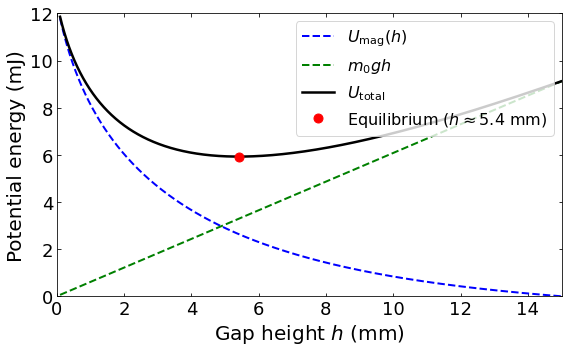

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, brentq

# ── Physical constants & geometry ────────────────────────────────────────────
mu_0  = 4*np.pi*1e-7
g     = 9.81
m0    = 62e-3       # kg, empty train mass
a     = 6.25e-3     # m, half-width
b     = 6.25e-2     # m, half-length
delta = 0.8e-3      # m, tape thickness

# ── Experimental data ─────────────────────────────────────────────────────────
m_exp_g  = np.array([0,5,15,20,26,31,36,43,51,63,71,85,90,103,117,
                     124,135,166,180,192,217,259,289,307,322], float)
h_exp_mm = np.array([5,4.8,4.3,4,3.7,3.5,3.3,2.9,2.8,2.8,2.7,2.1,
                     2,1.9,1.7,1.5,1.5,1.4,1.4,1.3,1.2,1,0.8,0.5,0], float)
m_exp = m_exp_g * 1e-3
h_exp = h_exp_mm  * 1e-3
mask  = h_exp > 0          # exclude contact point
m_fit = m_exp[mask]
h_fit = h_exp[mask]

# ── Force kernel (Akoun-Yonnet validated) ─────────────────────────────────────
def A_kernel(u, v, w):
    u, v, w = np.abs(u)+1e-15, np.abs(v)+1e-15, np.abs(w)+1e-15
    R   = np.sqrt(u**2 + v**2 + w**2)
    rho = np.sqrt(u**2 + v**2)
    return (w*u*np.log(R+u) - 0.5*w*R
            + 0.5*(u**2-v**2)*np.log((R+w)/(rho+1e-18))
            - 0.5*u*w*np.log(v**2+w**2)
            + 0.5*u*v*np.arctan(u*v/(w*R)))

def A_sym(u, v, w):
    return A_kernel(u, v, w) + A_kernel(v, u, w)

def S(z):
    return (A_sym(2*a, 2*b, z) - A_sym(2*a, 0, z)
          - A_sym(0,   2*b, z) + A_sym(0,   0, z))

def G(h):
    return S(h + 2*delta) - 2*S(h + delta) + S(h)

def F_one_pair(h, K):
    """Force from ONE rail pair."""
    return K * G(h)

def F_total(h, K):
    """Total upward force from TWO rail pairs."""
    return 2 * np.abs(F_one_pair(h, K))

# ── Fit K (P_mag = mu0*M^2/pi) ───────────────────────────────────────────────
sigma_m = 1e-3   # mass uncertainty

def residuals(params):
    K = np.exp(params[0])
    m_pred = F_total(h_fit, K) / g - m0
    return (m_pred - m_fit) / sigma_m

res   = least_squares(residuals, x0=[np.log(2.5e4)])
K_hat = float(np.exp(res.x[0]))
M_hat = np.sqrt(K_hat * np.pi / mu_0)
P_mag = K_hat
print(f"K_hat  = {K_hat:.4e} Pa")
print(f"M_hat  = {M_hat:.4e} A/m")

# ── Potential energy ──────────────────────────────────────────────────────────
h_energy = np.linspace(0.1e-3, 15e-3, 5000)
F_arr    = np.array([F_total(h, K_hat) for h in h_energy])

# U_mag(h) = integral from h to infinity of F(h') dh'
# Computed by right-to-left trapezoidal integration
U_mag = np.zeros_like(h_energy)
for i in range(len(h_energy)-2, -1, -1):
    U_mag[i] = (U_mag[i+1]
                + 0.5*(F_arr[i] + F_arr[i+1])
                * (h_energy[i+1] - h_energy[i]))

U_grav  = m0 * g * h_energy
U_total = U_mag + U_grav

idx_eq = np.argmin(U_total)
h_min  = h_energy[idx_eq]
print(f"Equilibrium gap: {h_min*1e3:.2f} mm")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'axes.labelsize' : 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'lines.linewidth': 2.5,
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(h_energy*1e3, U_mag*1e3,   'b--', linewidth=2,
        label=r'$U_{\mathrm{mag}}(h)$')
ax.plot(h_energy*1e3, U_grav*1e3,  'g--', linewidth=2,
        label=r'$m_0 g h$')
ax.plot(h_energy*1e3, U_total*1e3, 'k-',  linewidth=2.5,
        label=r'$U_{\mathrm{total}}$')
ax.plot(h_min*1e3, U_total[idx_eq]*1e3, 'ro', markersize=9, zorder=5,
        label=f'Equilibrium ($h \\approx {h_min*1e3:.1f}$ mm)')

ax.set_xlabel('Gap height $h$ (mm)')
ax.set_ylabel('Potential energy (mJ)')
ax.set_xlim(0, 15)
ax.set_ylim(0, 12)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()